In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,  # Vocabulary size ( as used by the BPE tokenizer)
    "context_length": 1024,  # Context length
    "emb_dim": 768,  # Embedding dimension
    "n_heads": 12,  # Number of attention heads
    "n_layers": 12,  # Number of layers
    "drop_rate": 0.1,  # Dropout rate
    "qkv_bias": False,  # Query-Key-Value bias
}

![Roadmap](1.png)

In [2]:
from torch import nn,arange


class GPT0(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.tok_emb = nn.Embedding(config["vocab_size"], config["emb_dim"])
        self.pos_emb = nn.Embedding(config["context_length"], config["emb_dim"])
        self.drop_emb = nn.Dropout(config["drop_rate"])
        self.trf_blocks = nn.ModuleList(
            [TransformerBlock0(config) for _ in range(config["n_layers"])]
        )
        self.final_norm = nn.LayerNorm(config["emb_dim"])
        self.out_head = nn.Linear(config["emb_dim"], config["vocab_size"])

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embds = self.pos_emb(in_idx)
        pos_embds = self.pos_emb(arange(seq_len), device=in_idx.device)
        x = tok_embds + pos_embds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class TransformerBlock0(nn.Module):
    def __init__(self, config):
        super().__init__()

    def forward(self, x):
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()

    def forward(self, x):
        return x


In [3]:
import torch
## Layer Normalization
class LayerNorm(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.eps = 1e-6
        self.scale = nn.Parameter(torch.ones(d_model))
        self.bias = nn.Parameter(torch.zeros(d_model))

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.scale * (x - mean) / (std + self.eps) + self.bias


## ReLU vs GELU

Both are activation functions (they add non-linearity between layers).

- **ReLU** `max(0, x)`: hard switch — negatives become exactly 0, with a sharp kink at 0.
- **GELU** `x · Φ(x)`: smooth version — negatives are mostly (not fully) suppressed, with a small dip below zero and a soft curve near 0.

GPT-2 uses **GELU** because it's smooth (better gradients), has no "dead neurons" (negatives still get a small gradient), and trains transformers to lower loss in practice. We use PyTorch's built-in `nn.GELU(approximate="tanh")` — same formula GPT-2 used, but a fast optimized kernel.

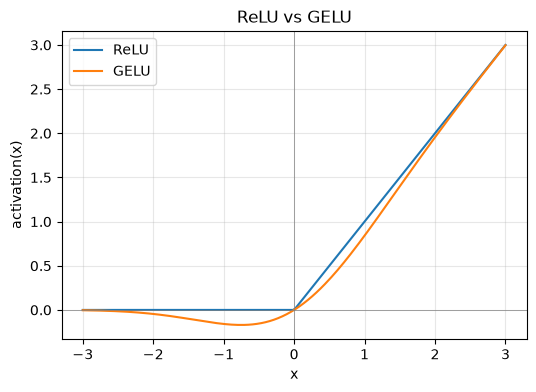

In [4]:
import torch
import matplotlib.pyplot as plt

# Built-in activations (real model -> use the optimized kernels)
relu = nn.ReLU()
gelu = nn.GELU(approximate="tanh")  # the variant GPT-2 uses

x = torch.linspace(-3, 3, 200)

plt.figure(figsize=(6, 4))
plt.plot(x, relu(x), label="ReLU")
plt.plot(x, gelu(x), label="GELU")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.title("ReLU vs GELU")
plt.xlabel("x")
plt.ylabel("activation(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [5]:
# MultiHeadAttention lives in a notebook in chapter 3, which can't be imported
# directly, so we import it from a small module that mirrors that class.
from previous_chapters import MultiHeadAttention


class FeedForward(nn.Module):
    """Position-wise MLP: expand 4x, GELU, project back down."""

    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            nn.GELU(approximate="tanh"),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


In [6]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.attn = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            num_heads=cfg["n_heads"],
            context_length=cfg["context_length"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )
        self.ff = FeedForward(cfg)
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Pre-LayerNorm: normalize BEFORE each sublayer, then add the residual.
        # Attention sublayer
        shortcut = x
        x = self.norm1(x)
        x = self.attn(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        # Feed-forward sublayer
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x


# Quick shape test: input and output shapes must match (the block is residual).
torch.manual_seed(123)
x = torch.rand(2, 4, GPT_CONFIG_124M["emb_dim"])  # [batch, num_tokens, emb_dim]
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)
print("input shape: ", x.shape)
print("output shape:", output.shape)


input shape:  torch.Size([2, 4, 768])
output shape: torch.Size([2, 4, 768])


In [7]:
class GPT(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.ModuleList(
            [TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

        # Weight tying (GPT-2): share the token-embedding matrix with the output
        # head. Both are [vocab_size, emb_dim], so the head reuses tok_emb's weights
        # instead of having its own ~38.6M-parameter matrix.
        self.out_head.weight = self.tok_emb.weight

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        # token + positional embeddings (ADD them, don't overwrite)
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # pos_embeds broadcasts over the batch
        x = self.drop_emb(x)
        for block in self.trf_blocks:
            x = block(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


# Quick test: feed a batch of token IDs, expect logits [batch, seq_len, vocab_size]
torch.manual_seed(123)
model = GPT(GPT_CONFIG_124M)
in_idx = torch.randint(0, GPT_CONFIG_124M["vocab_size"], (2, 4))  # [batch, seq_len]
logits = model(in_idx)
print("input shape: ", in_idx.shape)
print("logits shape:", logits.shape)

# Total counts each parameter tensor once; tied weights are shared, so they're
# only counted a single time -> matches GPT-2's reported 124M.
total_params = sum(p.numel() for p in model.parameters())
print(f"total parameters (tied):   {total_params:,}")

# For reference: what it would be WITHOUT tying (the untied 163M figure).
untied = total_params + model.tok_emb.weight.numel()
print(f"total parameters (untied): {untied:,}")


input shape:  torch.Size([2, 4])
logits shape: torch.Size([2, 4, 50257])
total parameters (tied):   124,412,160
total parameters (untied): 163,009,536


## Full GPT architecture

Data flow from token IDs to logits. **B** = batch, **T** = sequence length, **D** = `emb_dim` (768), **V** = `vocab_size` (50257).

```mermaid
flowchart TB
    in["in_idx &nbsp; [B, T]"]
    tok["Token Embedding"]
    pos["Positional Embedding"]
    add1["Add: tok + pos &nbsp; [B, T, D]"]
    drop0["Dropout"]

    in --> tok
    in --> pos
    tok --> add1
    pos --> add1
    add1 --> drop0

    subgraph blk["TransformerBlock  (x 12)"]
      direction TB
      x0([" block input "])
      n1["LayerNorm (norm1)"]
      attn["Multi-Head Attention<br/>causal mask + dropout"]
      r1["＋ residual"]
      n2["LayerNorm (norm2)"]
      ff["FeedForward<br/>Linear → GELU → Linear"]
      r2["＋ residual"]

      x0 --> n1 --> attn --> r1
      x0 -. skip .-> r1
      r1 --> n2 --> ff --> r2
      r1 -. skip .-> r2
    end

    drop0 --> x0
    r2 --> fn["LayerNorm (final_norm)"]
    fn --> head["Linear out_head &nbsp; [B, T, V]<br/>weights tied to tok_emb"]
    head --> out["logits &nbsp; [B, T, V]"]

    classDef emb fill:#cde7ff,stroke:#333,color:#000;
    classDef norm fill:#ffe2b0,stroke:#333,color:#000;
    classDef core fill:#d6f5d6,stroke:#333,color:#000;
    classDef add fill:#f6c6c6,stroke:#333,color:#000;
    classDef outp fill:#e7d6ff,stroke:#333,color:#000;
    class tok,pos emb;
    class n1,n2,fn norm;
    class attn,ff core;
    class add1,r1,r2 add;
    class head,out outp;
```

**Key ideas visible above:**
- **Two embeddings are added** (what each token is + where it sits).
- Each block has **two residual sublayers** (attention, then feed-forward), each using **Pre-LayerNorm** (the dotted `skip` arrows are the residual connections).
- The block is **stacked 12 times**; input/output shapes are identical, which is why it stacks.
- A **final LayerNorm** before the output head, whose weights are **tied** to the token embedding.
- Output is `[B, T, V]`: a vocab distribution at **every** position (only the last is used for generation).


In [9]:
def generate_text_simple(model,idx,max_new_tokens,context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:,-context_size:]  # crop context if needed to avoid out of bounds
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :] # get the logits for the last token 
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas,dim=-1,keepdim=True)
        idx = torch.cat((idx, idx_next),dim=-1)
    return idx

In [10]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")  # the BPE tokenizer GPT-2 was trained with

start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print(encoded)

# Use torch.tensor (lowercase) so the IDs stay integers (int64), which nn.Embedding
# requires. torch.Tensor(...) would make them float32 and the embedding lookup fails.
encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # add batch dim -> [1, seq_len]
print(encoded_tensor)
print("shape:", encoded_tensor.shape)


[15496, 11, 314, 716]
tensor([[15496,    11,   314,   716]])
shape: torch.Size([1, 4])


In [11]:
model.eval()  # disable dropout for deterministic generation
out = generate_text_simple(
    model,
    encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"],
)
print("output ids:", out)

# Decode back to text. .squeeze(0) drops the batch dim, .tolist() -> Python ints.
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print("output text:", decoded_text)
# NOTE: the model is untrained (random weights), so the continuation is gibberish.
# Training happens in chapter 5.


output ids: tensor([[15496,    11,   314,   716,   716,   716,   716,   716,   716,   716]])
output text: Hello, I am am am am am am am
